Notebook for illustrating the optimizations done in the gradient computation on the restricted state space.

In [1]:
import mhn
from mhn.optimizers import Optimizer, Device
import pandas as pd
import time
import matplotlib.pyplot as plt
import math
import numpy as np

np.random.seed(123)


c:\Users\michi\Uni\SHK_Spang\learnmhn_state-space-optimization\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


For performance evaluation we are interested in whether CUDA optimizations are available on our machine

In [2]:
mhn.CUDA_AVAILABLE

'CUDA is available'

In [3]:
opt = Optimizer()
opt.set_penalty(opt.Penalty.L1)

In [4]:
input = pd.read_csv('LUAD_n12.csv')

[235, 201, 18, 13, 408, 477, 3, 349, 31, 0, 349, 0, 0, 7, 0, 2, 0, 0, 0, 0, 0, 2, 0, 32, 24, 1, 0, 0, 0, 0, 0, 0, 0, 0, 12, 0, 0, 32, 0, 0, 0, 0, 0, 44, 76, 41, 0, 0, 0, 1, 0, 9, 3, 22, 21, 0, 0, 0, 0, 8, 3, 0, 0, 0, 0, 1, 0, 0, 0, 0, 6, 0, 0, 0, 0, 5, 0, 0, 0, 76, 0, 0, 0, 0, 0, 0, 0, 68, 0, 0, 20, 0, 0, 0, 28, 0, 3, 5, 0, 0, 0, 0, 0, 0, 1, 0, 1, 2, 48, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 7, 0, 0, 5, 0, 0, 5, 0, 10, 0, 0, 0, 0, 0, 0, 0, 23, 29, 0, 0, 28, 10, 0, 0, 0, 4, 0, 21, 3, 5, 0, 0, 0, 1, 0, 18, 0, 0, 0, 0, 13, 0, 0, 24, 51, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 20, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 18, 0, 1, 13, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 3, 0, 0, 0, 0, 2, 30, 0, 15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 0, 0, 1, 0, 1, 0, 0, 1, 8, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 3, 0, 1, 0, 0, 1, 0, 0, 0, 2, 0

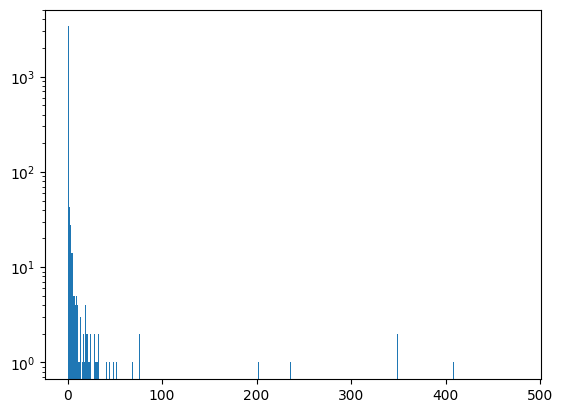

In [5]:
opt.load_data_matrix(input)
repetitions=opt._data.get_repetition_descriptor()
print(repetitions)
print(sum(repetitions))
print(f"{sum([1 if r==0 else 0 for r in repetitions])} / {len(input)} are redundant samples")
plt.hist(repetitions, bins=max(repetitions))
plt.yscale('log')
plt.show()

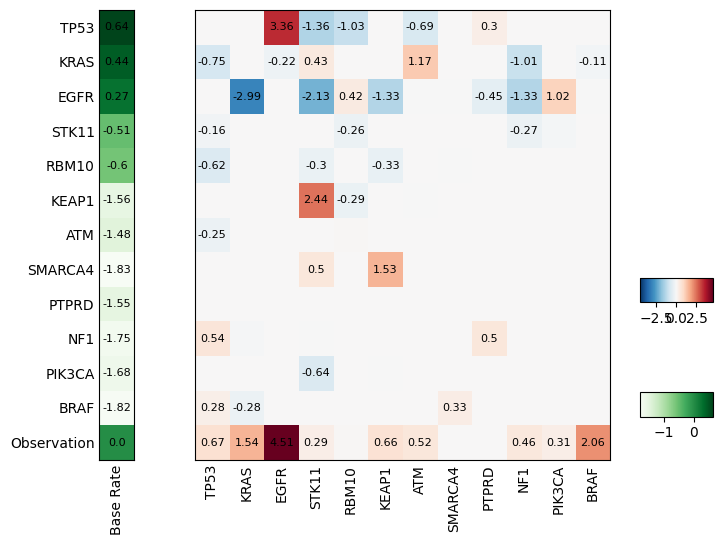

In [6]:
opt.train(5/len(input))
opt.result.plot()
plt.show()

In [ ]:


dataset_fractions = [0.1, 0.25, 0.5, 0.75, 1, 1.5, 2, 4, 10]
N=len(input)
computation_times={frac:[] for frac in dataset_fractions}

repetitions=5
for i in range(repetitions):
    for dataset_fraction in dataset_fractions:
        #input_subset = input.sample(frac=dataset_fraction, replace=True, random_state=6)
        input_subset = np.tile(input, (math.ceil(dataset_fraction),1))[:int(N*dataset_fraction)]

        opt.load_data_matrix(input_subset)

        #measure time optimization takes
        start = time.process_time()
        opt.train()
        end = time.process_time()

        time_elapsed= end-start
        computation_times[dataset_fraction].append(time_elapsed)
        print(f"{dataset_fraction} fraction of dataset   \t CPU time: {time_elapsed} seconds")



C:\Users\michi\Uni\SHK_Spang\learnmhn_state-space-optimization\mhn\optimizers.py:287: UserWarning: The dtype of the given data matrix is changed to np.int32
  warnings.warn(


0.1 fraction of dataset   	 CPU time: 0.484375 seconds
0.25 fraction of dataset   	 CPU time: 0.765625 seconds
0.5 fraction of dataset   	 CPU time: 1.171875 seconds
0.75 fraction of dataset   	 CPU time: 1.65625 seconds
1 fraction of dataset   	 CPU time: 1.96875 seconds
1.5 fraction of dataset   	 CPU time: 1.828125 seconds
2 fraction of dataset   	 CPU time: 3.296875 seconds


KeyboardInterrupt: 

Exception ignored in: 'mhn.training.state_containers.construct_repetition_descriptor'
Traceback (most recent call last):
  File "c:\Users\michi\Uni\SHK_Spang\learnmhn_state-space-optimization\.venv\Lib\site-packages\numpy\core\numeric.py", line 2433, in array_equal
    a1, a2 = asarray(a1), asarray(a2)
             ^^^^^^^^^^^
KeyboardInterrupt: 


4 fraction of dataset   	 CPU time: 8.90625 seconds


In [ ]:
comp_times_df=pd.DataFrame.from_dict(computation_times)

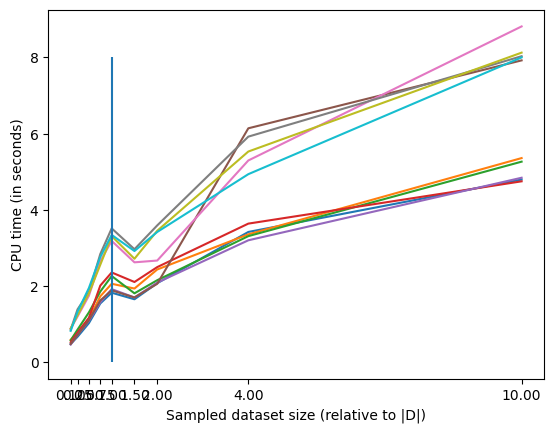

In [ ]:
comp_times_df.T.plot(xlabel="Sampled dataset size (relative to |D|)", ylabel="CPU time (in seconds)", xticks=dataset_fractions, legend=False)
plt.vlines(1,0,8)